# Norwegian Continental Shelf: spatial history, discoveries, and future potential

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/ncs_spatial_history_discoveries_and_future_potential.ipynb)

This notebook treats the Norwegian Continental Shelf (NCS) as an evolving system.
It links the history of licensing, exploration, discoveries, fields, facilities, and
pipelines to today's undeveloped-discovery portfolio and to transparent future-opportunity
screens. Official Norwegian Offshore Directorate (SODIR) data are retrieved from FactMaps,
while NeqSim Java `master` tests whether selected gas discoveries have plausible pressure
margin in a deliberately generic subsea tie-back.

**Learning outcomes**

1. Retrieve and quality-check official NCS layers through the ArcGIS REST interface.
2. Reconstruct how exploration and infrastructure migrated from the North Sea northwards.
3. Compare discovery rates, resource maturity, and infrastructure proximity by sea area.
4. Rank undeveloped discoveries without confusing an open-data screen with a project study.
5. Pass spatially derived tie-back lengths and public resource estimates into NeqSim.
6. Separate near-field development opportunities from frontier exploration potential.


## Decision questions and strict boundaries

The notebook asks three related questions.

- How did early licensing and discoveries create the present NCS infrastructure pattern?
- Which public undeveloped discoveries combine resource scale, maturity, and proximity to
  existing facilities?
- Which sea areas combine remaining undiscovered potential with different knowledge and
  infrastructure histories?

The answers are **screening evidence only**. Distance is not a route, proximity is not
capacity, a SODIR resource estimate is not a reserves booking, and a NeqSim generic-fluid
result is not flow assurance. No prospect, discovery, field, host, or investment decision
should be based on this notebook without governed seismic, well, fluid, reservoir, facility,
commercial, environmental, and regulatory data.


## 0. Clean Colab runtime and NeqSim Java master

The Python package is used as the JPype bridge. The demonstrated Java calculations are
loaded from a source-built `equinor/neqsim` `master` JAR. The resolved commit and JAR hash
are retained in the notebook output.


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys

REQUIRED_PACKAGES = {
    "neqsim": "neqsim==3.16.0",
    "requests": "requests>=2.32,<3",
    "pandas": "pandas>=2.2,<3",
    "numpy": "numpy>=2.0,<3",
    "matplotlib": "matplotlib>=3.9,<4",
    "geopandas": "geopandas>=1.0,<2",
    "shapely": "shapely>=2.0,<3",
    "pyproj": "pyproj>=3.6,<4",
    "sklearn": "scikit-learn>=1.5,<2",
}

missing_specs = []
for import_name, package_spec in REQUIRED_PACKAGES.items():
    distribution_name = "scikit-learn" if import_name == "sklearn" else import_name
    try:
        version(distribution_name)
    except PackageNotFoundError:
        missing_specs.append(package_spec)

if missing_specs:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *missing_specs],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-master")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError("NeqSim master did not produce a runtime JAR.")
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import jpype

if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before NeqSim master was selected. Restart and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
from neqsim.neqsimpython import init_jvm

init_jvm()
SOURCE_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Loaded Java classes from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")


NeqSim Python bridge: 3.16.0
NeqSim source ref: master
NeqSim source commit: 7ae08253b45180045a99a700314f23c9a7001b3c
NeqSim source JAR SHA-256: a644ebbeabebab43be72003fe6d7a23539ec9673f81d2052eb46bd4172e0f64b
Loaded Java classes from: file:/tmp/neqsim-ncs-spatial-ufrZjz/target/neqsim-3.16.0.jar
Python runtime: 3.12.13


In [2]:
from datetime import datetime, timezone
from importlib.metadata import version
import math
import time
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display
from matplotlib.lines import Line2D
from shapely.geometry import Point

warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 48)

SESSION_UTC = datetime.now(timezone.utc).replace(microsecond=0).isoformat()
PROJECTED_CRS = "EPSG:3035"
package_names = [
    "pandas",
    "numpy",
    "matplotlib",
    "geopandas",
    "shapely",
    "pyproj",
    "requests",
    "scikit-learn",
]
package_versions = pd.DataFrame(
    {
        "package": package_names,
        "version": [version(name) for name in package_names],
    }
)
print("Open-data retrieval UTC:", SESSION_UTC)
display(package_versions)


Open-data retrieval UTC: 2026-08-05T17:48:33+00:00


,package,version
0,pandas,2.3.3
1,numpy,2.5.1
2,matplotlib,3.11.1
3,geopandas,1.1.4
4,shapely,2.1.2
5,pyproj,3.7.2
6,requests,2.34.2
7,scikit-learn,1.9.0


## 1. Official open-data contract

SODIR FactMaps is synchronised with the Directorate's databases daily and is published
under the Norwegian Licence for Open Government Data (NLOD 2.0). The workflow uses stable
numeric layer identifiers, explicit fields, pagination, WGS84 for exchange, and
ETRS89-LAEA Europe (`EPSG:3035`) for approximate shelf-scale distances.

| Evidence | FactMaps layer/table | Use here |
|---|---:|---|
| Wildcat wellbores | 201 | exploration intensity and discovery-well fraction |
| Facilities in place | 304 | host-proximity proxy and infrastructure history |
| Pipelines | 311 | current evacuation context and distance proxy |
| Fields | 502 | development geography and nearest-field proxy |
| Discoveries | 504 | discovery history, status, hydrocarbon type, geometry |
| Field resources | 515 | remaining-field-resource context; never capacity |
| Discovery resources | 532 | public contingent-resource screen |
| Plays | 540 | confirmed/unconfirmed play context |
| Current licences | 616 | licensing history and current acreage context |

Dates, names, polygons, and resource figures can be revised. The retrieval timestamp and
layer row counts below are therefore part of the result.


In [3]:
ARCGIS = (
    "https://factmaps.sodir.no/api/rest/services/"
    "Factmaps/FactMapsWGS84/FeatureServer"
)
HTTP = requests.Session()
HTTP.headers.update({"User-Agent": "NeqSim-Colab-open-NCS-study/1.0"})


def arcgis_query(
    layer_id,
    out_fields,
    where="1=1",
    return_geometry=False,
    page_size=250,
):
    all_features = []
    offset = 0
    output_format = "geojson" if return_geometry else "json"

    while True:
        params = {
            "where": where,
            "outFields": ",".join(out_fields),
            "returnGeometry": str(return_geometry).lower(),
            "outSR": 4326,
            "orderByFields": "OBJECTID",
            "resultOffset": offset,
            "resultRecordCount": page_size,
            "f": output_format,
        }
        response = None
        for attempt in range(5):
            response = HTTP.get(
                f"{ARCGIS}/{layer_id}/query",
                params=params,
                timeout=120,
            )
            if response.status_code < 500:
                break
            time.sleep(2**attempt)
        response.raise_for_status()
        payload = response.json()
        if "error" in payload:
            raise RuntimeError(payload["error"])

        features = payload.get("features", [])
        all_features.extend(features)
        if len(features) < page_size:
            break
        offset += len(features)

    if return_geometry:
        return gpd.GeoDataFrame.from_features(
            all_features,
            crs="EPSG:4326",
        )

    rows = [feature["attributes"] for feature in all_features]
    return pd.DataFrame(rows)


discoveries = arcgis_query(
    504,
    [
        "OBJECTID",
        "dscNpdidDiscovery",
        "dscName",
        "dscCurrentActivityStatus",
        "dscDiscoveryYear",
        "dscHcType",
        "nmaName",
        "fldName",
        "dscDateUpdated",
        "dscFactPageUrl",
    ],
    return_geometry=True,
)
fields = arcgis_query(
    502,
    [
        "OBJECTID",
        "fldNpdidField",
        "fldName",
        "fldCurrentActivitySatus",
        "fldDiscoveryYear",
        "fldHcType",
        "fldMainArea",
    ],
    return_geometry=True,
)
facilities = arcgis_query(
    304,
    [
        "OBJECTID",
        "fclNpdidFacility",
        "fclName",
        "fclPhase",
        "fclFunctions",
        "fclStartupDate",
        "fclWaterDepth",
        "fclBelongsToName",
        "fclNationName",
    ],
    where="fclNationName='Norway'",
    return_geometry=True,
)
pipelines = arcgis_query(
    311,
    [
        "OBJECTID",
        "pplNpdidPipeline",
        "pplName",
        "pplCurrentPhase",
        "pplCurrentPhaseFromDate",
        "pplMedium",
        "pplDimension",
        "fclNameFrom",
        "fclNameTo",
    ],
    where="pplCurrentPhase='IN SERVICE'",
    return_geometry=True,
)
wildcats = arcgis_query(
    201,
    [
        "OBJECTID",
        "wlbNpdidWellbore",
        "wlbWellboreName",
        "wlbEntryYear",
        "wlbMainArea",
        "wlbDiscoveryWellbore",
        "wlbContent",
        "wlbStatus",
    ],
    where="wlbPurpose='WILDCAT'",
    return_geometry=True,
)
plays = arcgis_query(
    540,
    [
        "OBJECTID",
        "plyNPDID",
        "plyName",
        "plyConfirmed",
        "plyRegion",
        "plyAge",
        "plyGroupName",
    ],
    return_geometry=True,
)
licences = arcgis_query(
    616,
    [
        "OBJECTID",
        "prlNpdidLicence",
        "prlName",
        "prlLicensingActivityName",
        "prlStatus",
        "prlDateGranted",
        "prlOriginalArea",
        "prlCurrentArea",
        "prlMainArea",
        "cmpLongName",
    ],
)
discovery_resources = arcgis_query(
    532,
    [
        "OBJECTID",
        "dscNpdidDiscovery",
        "dscDateOffResEstDisplay",
        "dscRecoverableOil",
        "dscRecoverableGas",
        "dscRecoverableNGL",
        "dscRecoverableCondensate",
        "dscRecoverableOe",
        "dscReservesRC",
    ],
)
field_resources = arcgis_query(
    515,
    [
        "OBJECTID",
        "fldNpdidField",
        "fldDateOffResEstDisplay",
        "fldRemainingOil",
        "fldRemainingGas",
        "fldRemainingNGL",
        "fldRemainingCondensate",
        "fldRemainingOE",
    ],
)

resource_value_columns = [
    "dscRecoverableOil",
    "dscRecoverableGas",
    "dscRecoverableNGL",
    "dscRecoverableCondensate",
    "dscRecoverableOe",
]
discovery_resources = (
    discovery_resources.groupby("dscNpdidDiscovery", as_index=False)
    .agg(
        {
            "dscDateOffResEstDisplay": "max",
            **{column: "sum" for column in resource_value_columns},
            "dscReservesRC": lambda values: "+".join(
                sorted(set(values.dropna().astype(str)))
            ),
        }
    )
)

print("SODIR layers retrieved successfully.")


SODIR layers retrieved successfully.


In [4]:
AREA_NAMES = {
    "North sea": "North Sea",
    "Norwegian sea": "Norwegian Sea",
    "Barents sea": "Barents Sea",
}


def normalize_area(series):
    return series.astype("string").str.strip().str.title().replace(AREA_NAMES)


discoveries["sea_area"] = normalize_area(discoveries["nmaName"])
fields["sea_area"] = normalize_area(fields["fldMainArea"])
wildcats["sea_area"] = normalize_area(wildcats["wlbMainArea"])
licences["sea_area"] = normalize_area(licences["prlMainArea"])
plays["sea_area"] = plays["plyRegion"].str.replace(" sea", " Sea", regex=False)

date_columns = [
    (discoveries, "dscDateUpdated"),
    (facilities, "fclStartupDate"),
    (pipelines, "pplCurrentPhaseFromDate"),
    (licences, "prlDateGranted"),
    (discovery_resources, "dscDateOffResEstDisplay"),
    (field_resources, "fldDateOffResEstDisplay"),
]
for frame, column in date_columns:
    frame[column] = pd.to_datetime(
        frame[column],
        unit="ms",
        errors="coerce",
    )

geometry_frames = {
    "discoveries": discoveries,
    "fields": fields,
    "facilities": facilities,
    "in-service pipelines": pipelines,
    "wildcat wellbores": wildcats,
    "plays": plays,
}
audit_rows = []
for name, frame in geometry_frames.items():
    valid_geometry = frame.geometry.notna() & ~frame.geometry.is_empty
    audit_rows.append(
        {
            "dataset": name,
            "rows": len(frame),
            "valid_geometry_pct": 100.0 * valid_geometry.mean(),
            "crs": str(frame.crs),
        }
    )
audit_rows.extend(
    [
        {
            "dataset": "current licences",
            "rows": len(licences),
            "valid_geometry_pct": np.nan,
            "crs": "attributes only",
        },
        {
            "dataset": "discovery resources",
            "rows": len(discovery_resources),
            "valid_geometry_pct": np.nan,
            "crs": "attributes only",
        },
        {
            "dataset": "field resources",
            "rows": len(field_resources),
            "valid_geometry_pct": np.nan,
            "crs": "attributes only",
        },
    ]
)
data_audit = pd.DataFrame(audit_rows)
display(data_audit.round(1))

assert discoveries["dscNpdidDiscovery"].is_unique
assert discovery_resources["dscNpdidDiscovery"].is_unique
assert fields["fldNpdidField"].is_unique
assert set(discoveries["sea_area"].dropna().unique()).issubset(
    {"North Sea", "Norwegian Sea", "Barents Sea"}
)


,dataset,rows,valid_geometry_pct,crs
0,discoveries,646,92.6,EPSG:4326
1,fields,142,99.3,EPSG:4326
2,facilities,886,83.5,EPSG:4326
3,in-service pipelines,69,92.8,EPSG:4326
4,wildcat wellbores,1434,100.0,EPSG:4326
5,plays,71,100.0,EPSG:4326
6,current licences,1812,NaN,attributes only
7,discovery resources,95,NaN,attributes only
8,field resources,139,NaN,attributes only


## 2. History as an analytical variable

NCS history is not decoration. Early North Sea discoveries justified processing and export
systems; those systems subsequently reduced the threshold for nearby discoveries. The
Norwegian Sea and Barents Sea started later and therefore have different data density,
host choices, and export constraints.

Official milestones used below include the 1965 first licensing round, the first well in
1966, Balder in 1967, Ekofisk in 1969 and first production in 1971, opening north of 62°N
in 1980, first Barents Sea production from Snøhvit in 2007, and Johan Sverdrup production
from 2019. The dynamic curves themselves come from the live SODIR datasets.


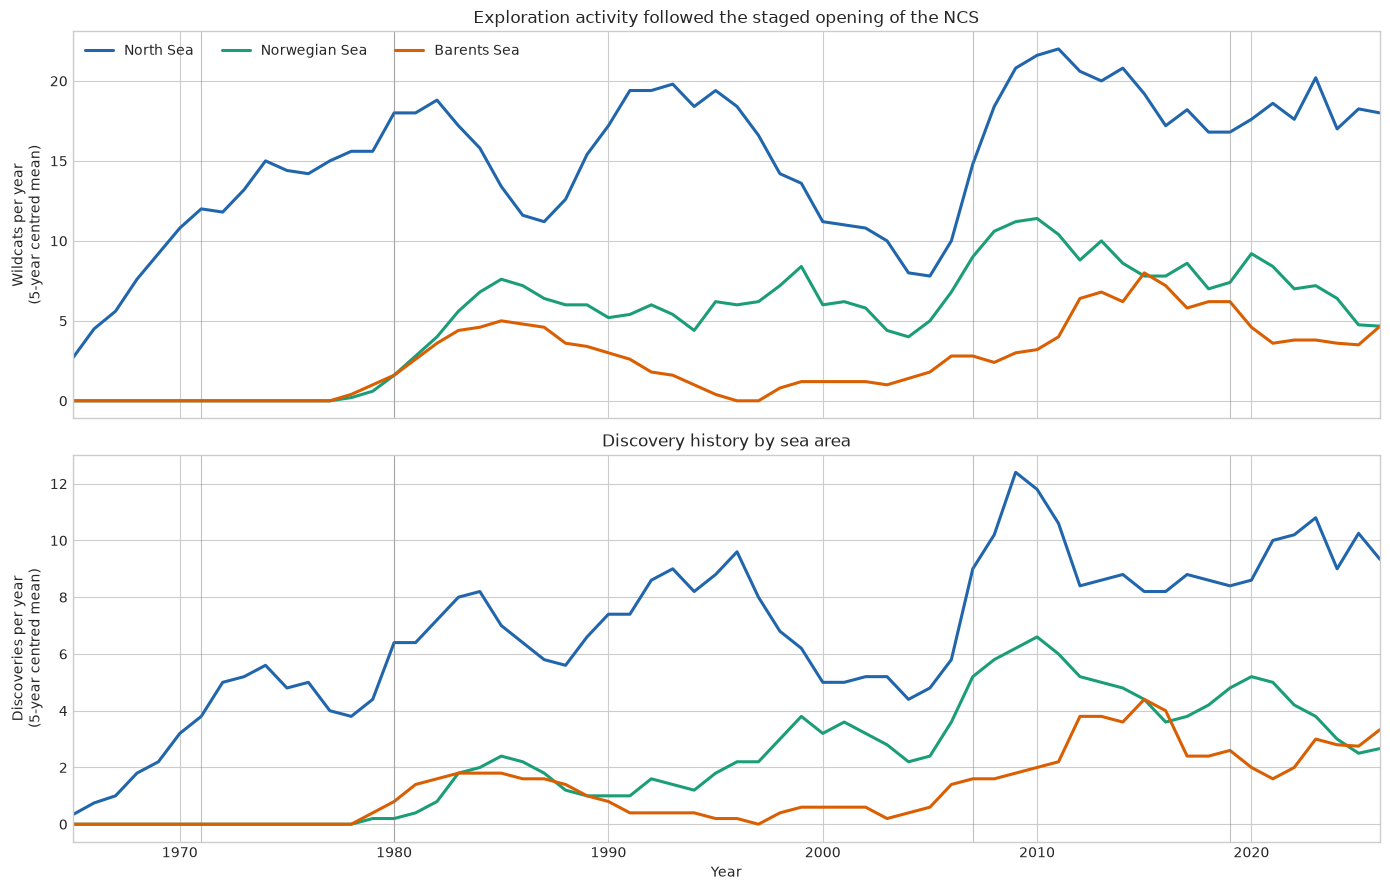

,year,milestone
0,1965,First licensing round: 22 licences / 78 blocks
1,1966,First exploration well; dry
2,1967,Balder discovery
3,1969,Ekofisk discovery
4,1971,Ekofisk test production; NCS production begins
5,1977,Norwegian gas exports begin
6,1980,Norwegian and Barents seas opened
7,2007,Snøhvit: first Barents Sea production
8,2019,Johan Sverdrup Phase I production
9,2025,239.2 million Sm3 o.e. total NCS production


In [5]:
milestones = pd.DataFrame(
    [
        [1965, "First licensing round: 22 licences / 78 blocks"],
        [1966, "First exploration well; dry"],
        [1967, "Balder discovery"],
        [1969, "Ekofisk discovery"],
        [1971, "Ekofisk test production; NCS production begins"],
        [1977, "Norwegian gas exports begin"],
        [1980, "Norwegian and Barents seas opened"],
        [2007, "Snøhvit: first Barents Sea production"],
        [2019, "Johan Sverdrup Phase I production"],
        [2025, "239.2 million Sm3 o.e. total NCS production"],
    ],
    columns=["year", "milestone"],
)

discovery_history = (
    discoveries.dropna(subset=["dscDiscoveryYear", "sea_area"])
    .assign(year=lambda frame: frame["dscDiscoveryYear"].astype(int))
    .query("1965 <= year <= 2026")
    .groupby(["year", "sea_area"])
    .size()
    .rename("discoveries")
    .reset_index()
)
well_history = (
    wildcats.dropna(subset=["wlbEntryYear", "sea_area"])
    .assign(year=lambda frame: frame["wlbEntryYear"].astype(int))
    .query("1965 <= year <= 2026")
    .groupby(["year", "sea_area"])
    .size()
    .rename("wildcats")
    .reset_index()
)

years = pd.Index(range(1965, 2027), name="year")
areas = ["North Sea", "Norwegian Sea", "Barents Sea"]
colors = {
    "North Sea": "#2166ac",
    "Norwegian Sea": "#1b9e77",
    "Barents Sea": "#d95f02",
}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for sea_area in areas:
    discovery_series = (
        discovery_history.query("sea_area == @sea_area")
        .set_index("year")["discoveries"]
        .reindex(years, fill_value=0)
        .rolling(5, center=True, min_periods=1)
        .mean()
    )
    well_series = (
        well_history.query("sea_area == @sea_area")
        .set_index("year")["wildcats"]
        .reindex(years, fill_value=0)
        .rolling(5, center=True, min_periods=1)
        .mean()
    )
    axes[0].plot(
        years,
        well_series,
        color=colors[sea_area],
        linewidth=2.2,
        label=sea_area,
    )
    axes[1].plot(
        years,
        discovery_series,
        color=colors[sea_area],
        linewidth=2.2,
        label=sea_area,
    )

for year in [1965, 1971, 1980, 2007, 2019]:
    for axis in axes:
        axis.axvline(year, color="#777777", linewidth=0.8, alpha=0.45)
axes[0].set_ylabel("Wildcats per year\n(5-year centred mean)")
axes[0].set_title("Exploration activity followed the staged opening of the NCS")
axes[0].legend(ncol=3, loc="upper left")
axes[1].set_ylabel("Discoveries per year\n(5-year centred mean)")
axes[1].set_xlabel("Year")
axes[1].set_title("Discovery history by sea area")
axes[1].set_xlim(1965, 2026)
plt.tight_layout()
plt.show()

display(milestones)


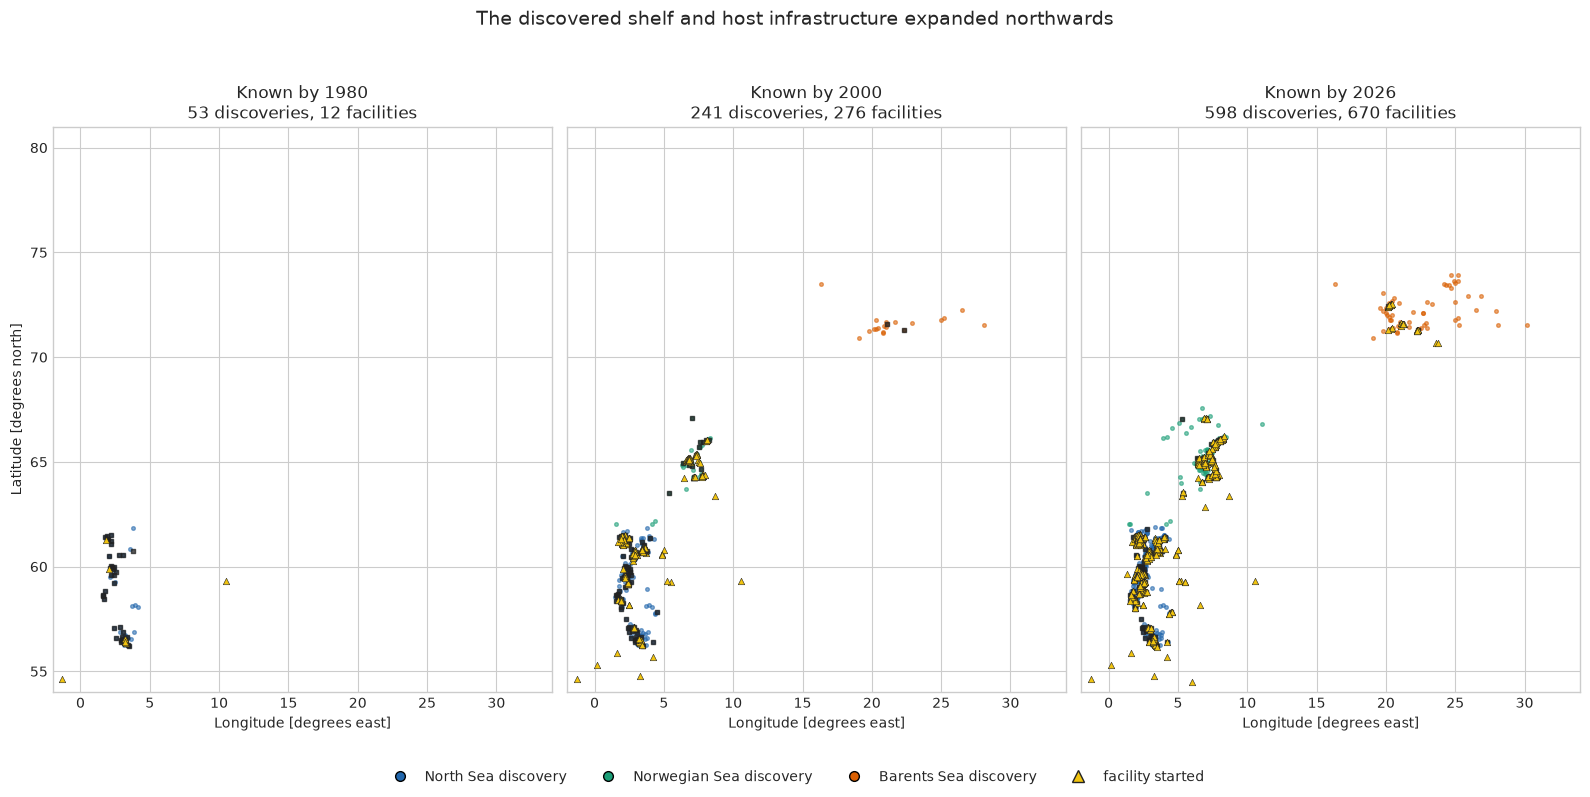

In [6]:
discovery_points = discoveries.copy()
discovery_points["geometry"] = discovery_points.geometry.representative_point()
field_points = fields.copy()
field_points["geometry"] = field_points.geometry.representative_point()

snapshots = [1980, 2000, 2026]
fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharex=True, sharey=True)
for axis, snapshot_year in zip(axes, snapshots):
    active_discoveries = discovery_points[
        discovery_points["dscDiscoveryYear"].fillna(9999) <= snapshot_year
    ].copy()
    active_fields = field_points[
        field_points["fldDiscoveryYear"].fillna(9999) <= snapshot_year
    ].copy()
    active_facilities = facilities[
        facilities["fclStartupDate"].dt.year.fillna(9999) <= snapshot_year
    ].copy()
    active_discoveries = active_discoveries[
        active_discoveries.geometry.notna()
        & ~active_discoveries.geometry.is_empty
    ]
    active_fields = active_fields[
        active_fields.geometry.notna() & ~active_fields.geometry.is_empty
    ]
    active_facilities = active_facilities[
        active_facilities.geometry.notna()
        & ~active_facilities.geometry.is_empty
    ]

    for sea_area in areas:
        subset = active_discoveries.query("sea_area == @sea_area")
        subset = subset[subset.geometry.notna() & ~subset.geometry.is_empty]
        if not subset.empty:
            subset.plot(
                ax=axis,
                color=colors[sea_area],
                markersize=7,
                alpha=0.55,
            )
    if not active_fields.empty:
        active_fields.plot(
            ax=axis,
            color="#222222",
            marker="s",
            markersize=10,
            alpha=0.75,
        )
    if not active_facilities.empty:
        active_facilities.plot(
            ax=axis,
            color="#f1c40f",
            edgecolor="#222222",
            marker="^",
            markersize=22,
            linewidth=0.4,
        )
    axis.set_title(
        f"Known by {snapshot_year}\n"
        f"{len(active_discoveries)} discoveries, "
        f"{len(active_facilities)} facilities"
    )
    axis.set_xlim(-2, 34)
    axis.set_ylim(54, 81)
    axis.set_xlabel("Longitude [degrees east]")
    axis.set_aspect("auto")

axes[0].set_ylabel("Latitude [degrees north]")
legend_items = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=colors[area],
        label=f"{area} discovery",
        markersize=7,
    )
    for area in areas
]
legend_items.append(
    Line2D(
        [0],
        [0],
        marker="^",
        color="none",
        markerfacecolor="#f1c40f",
        markeredgecolor="#222222",
        label="facility started",
        markersize=8,
    )
)
fig.legend(handles=legend_items, loc="lower center", ncol=4)
fig.suptitle(
    "The discovered shelf and host infrastructure expanded northwards",
    y=0.98,
    fontsize=14,
)
plt.tight_layout(rect=(0, 0.06, 1, 0.95))
plt.show()


## 3. Exploration learning and present maturity

A discovery-well fraction is a descriptive historical ratio, not a geological chance of
success for a future prospect. It is affected by data classification, appraisal strategy,
commercial context, technology, and the sequence in which prospects were drilled.
Nevertheless, combined with wildcat density and play confirmation it reveals how much
empirical learning has accumulated in each sea area.


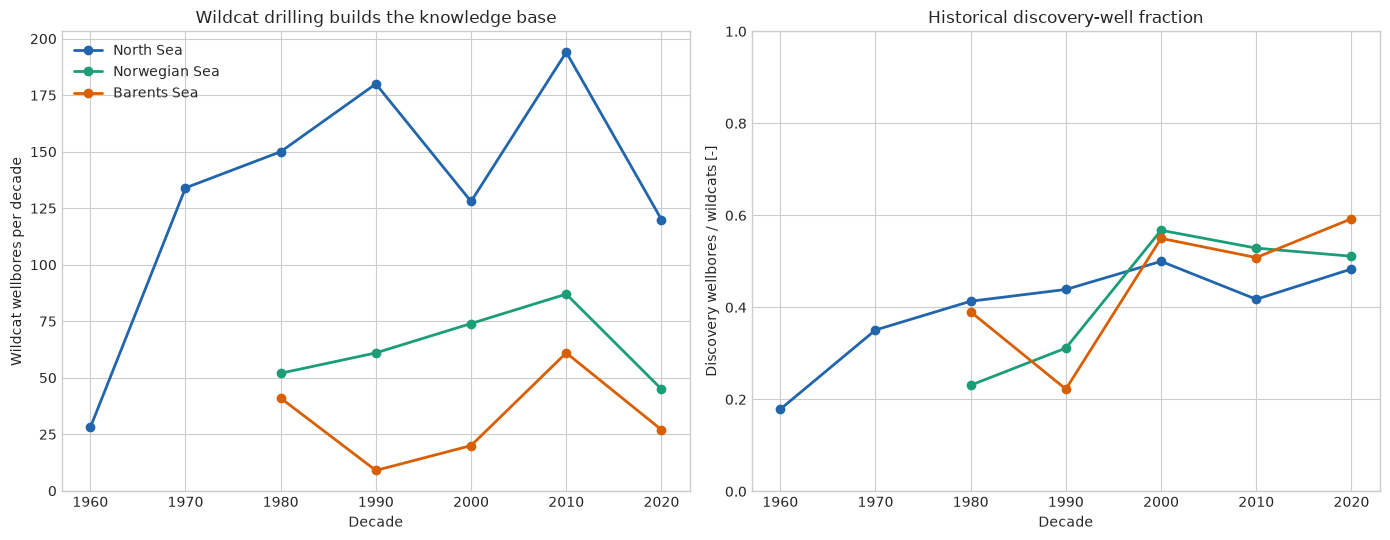

,mapped_plays,confirmed_plays,confirmed_play_share
sea_area,,,
Barents Sea,25,15,0.600
North Sea,25,21,0.840
Norwegian Sea,21,12,0.571


In [7]:
wildcat_history = wildcats.dropna(subset=["wlbEntryYear", "sea_area"]).copy()
wildcat_history["year"] = wildcat_history["wlbEntryYear"].astype(int)
wildcat_history["decade"] = 10 * (wildcat_history["year"] // 10)
wildcat_history["discovery_well"] = (
    wildcat_history["wlbDiscoveryWellbore"]
    .fillna("")
    .str.upper()
    .isin(["YES", "Y"])
)
decade_screen = (
    wildcat_history.query("1960 <= decade <= 2020")
    .groupby(["sea_area", "decade"])
    .agg(
        wildcats=("wlbNpdidWellbore", "count"),
        discovery_wells=("discovery_well", "sum"),
    )
    .reset_index()
)
decade_screen["discovery_well_fraction"] = (
    decade_screen["discovery_wells"] / decade_screen["wildcats"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for sea_area in areas:
    subset = decade_screen.query("sea_area == @sea_area")
    axes[0].plot(
        subset["decade"],
        subset["wildcats"],
        marker="o",
        linewidth=2,
        color=colors[sea_area],
        label=sea_area,
    )
    axes[1].plot(
        subset["decade"],
        subset["discovery_well_fraction"],
        marker="o",
        linewidth=2,
        color=colors[sea_area],
        label=sea_area,
    )
axes[0].set_title("Wildcat drilling builds the knowledge base")
axes[0].set_ylabel("Wildcat wellbores per decade")
axes[0].set_xlabel("Decade")
axes[1].set_title("Historical discovery-well fraction")
axes[1].set_ylabel("Discovery wellbores / wildcats [-]")
axes[1].set_xlabel("Decade")
axes[1].set_ylim(0, 1)
axes[0].legend()
plt.tight_layout()
plt.show()

play_summary = (
    plays.assign(
        confirmed=plays["plyConfirmed"].fillna("").str.upper().eq("YES")
    )
    .groupby("sea_area")
    .agg(
        mapped_plays=("plyNPDID", "nunique"),
        confirmed_plays=("confirmed", "sum"),
    )
)
play_summary["confirmed_play_share"] = (
    play_summary["confirmed_plays"] / play_summary["mapped_plays"]
)
display(play_summary.round(3))


## 4. Undeveloped-discovery and infrastructure screen

The public discovery-development score is

$$S=100\left(0.35R+0.25F+0.15H+0.25M\right)$$

where $R$ is the percentile of log recoverable oil-equivalent volume, $F$ is an
exponential facility-proximity score, $H$ is an exponential nearest-field score, and $M$
is a status-maturity weight. Distances are straight-line shelf-scale distances in
`EPSG:3035`; they do not account for bathymetry, exclusions, landfalls, routing, ownership,
tariffs, pressure, composition, uptime, or spare capacity.

The score intentionally omits economics and geological prospectivity. It answers only:
*which published discoveries deserve the next open-data screening step?*


In [8]:
development_status_weight = {
    "Approved for production": 1.00,
    "Production in clarification phase": 0.82,
    "Production likely but unclarified": 0.62,
    "Production not evaluated": 0.42,
}
eligible_statuses = set(development_status_weight)

portfolio = discoveries[
    discoveries["dscCurrentActivityStatus"].isin(eligible_statuses)
].copy()
portfolio = portfolio.merge(
    discovery_resources,
    on="dscNpdidDiscovery",
    how="left",
    validate="one_to_one",
)
portfolio = gpd.GeoDataFrame(portfolio, geometry="geometry", crs="EPSG:4326")
portfolio = portfolio[portfolio.geometry.notna() & ~portfolio.geometry.is_empty].copy()

portfolio_projected = portfolio.to_crs(PROJECTED_CRS)
portfolio_projected["geometry"] = (
    portfolio_projected.geometry.representative_point()
)
facilities_projected = facilities.to_crs(PROJECTED_CRS)
fields_projected = fields.to_crs(PROJECTED_CRS)
fields_projected["geometry"] = fields_projected.geometry.representative_point()
pipelines_projected = pipelines.to_crs(PROJECTED_CRS)


def nearest_distance_km(point, geometry_series):
    distances = geometry_series.distance(point)
    return float(distances.min() / 1_000.0)


portfolio_projected["nearest_facility_km"] = [
    nearest_distance_km(point, facilities_projected.geometry)
    for point in portfolio_projected.geometry
]
portfolio_projected["nearest_field_km"] = [
    nearest_distance_km(point, fields_projected.geometry)
    for point in portfolio_projected.geometry
]
portfolio_projected["nearest_pipeline_km"] = [
    nearest_distance_km(point, pipelines_projected.geometry)
    for point in portfolio_projected.geometry
]

resource_oe = portfolio_projected["dscRecoverableOe"].fillna(0.0).clip(lower=0.0)
portfolio_projected["resource_score"] = np.log1p(resource_oe).rank(
    pct=True,
    method="average",
)
portfolio_projected["facility_score"] = np.exp(
    -portfolio_projected["nearest_facility_km"] / 80.0
)
portfolio_projected["field_score"] = np.exp(
    -portfolio_projected["nearest_field_km"] / 100.0
)
portfolio_projected["maturity_score"] = portfolio_projected[
    "dscCurrentActivityStatus"
].map(development_status_weight)
portfolio_projected["development_screen_score"] = 100.0 * (
    0.35 * portfolio_projected["resource_score"]
    + 0.25 * portfolio_projected["facility_score"]
    + 0.15 * portfolio_projected["field_score"]
    + 0.25 * portfolio_projected["maturity_score"]
)
portfolio = portfolio_projected.to_crs("EPSG:4326")
portfolio = portfolio.sort_values(
    "development_screen_score",
    ascending=False,
)

ranking_columns = [
    "dscName",
    "sea_area",
    "dscHcType",
    "dscCurrentActivityStatus",
    "dscRecoverableOe",
    "dscRecoverableGas",
    "nearest_facility_km",
    "nearest_pipeline_km",
    "nearest_field_km",
    "development_screen_score",
]
display(portfolio[ranking_columns].head(15).round(2))


,dscName,sea_area,dscHcType,dscCurrentActivityStatus,dscRecoverableOe,dscRecoverableGas,nearest_facility_km,nearest_pipeline_km,nearest_field_km,development_screen_score
22,35/12-2 (Grosbeak),North Sea,OIL/GAS,Production in clarification phase,16.84,7.95,9.20,7.06,6.85,90.29
107,6507/4-2 S (Adriana Sabina),Norwegian Sea,GAS/CONDENSATE,Production in clarification phase,9.45,6.65,3.38,1.57,11.87,88.27
59,30/2-5 S (Atlantis),North Sea,GAS/CONDENSATE,Production in clarification phase,11.82,7.87,14.91,8.07,9.90,86.83
70,6507/2-6,Norwegian Sea,GAS,Production in clarification phase,6.38,5.93,2.28,11.60,8.84,85.25
89,35/10-15 S (Kjøttkake),North Sea,OIL/GAS,Production in clarification phase,7.03,0.67,10.19,4.74,12.26,84.01
31,34/6-2 S (Garantiana),North Sea,OIL,Production in clarification phase,11.08,0.00,19.06,28.77,23.94,83.62
64,31/1-2 S (Røver Nord),North Sea,OIL/GAS,Production in clarification phase,6.92,3.85,10.58,4.54,13.80,83.32
71,35/6-3 S (Ofelia),North Sea,OIL,Production in clarification phase,7.20,3.26,14.00,4.35,13.30,83.22
77,35/10-10 S (Carmen),North Sea,GAS/CONDENSATE,Production in clarification phase,10.33,7.00,19.21,1.41,24.01,83.20
68,35/10-7 S (Toppand),North Sea,GAS/CONDENSATE,Production in clarification phase,5.81,3.85,9.98,2.33,15.66,81.36


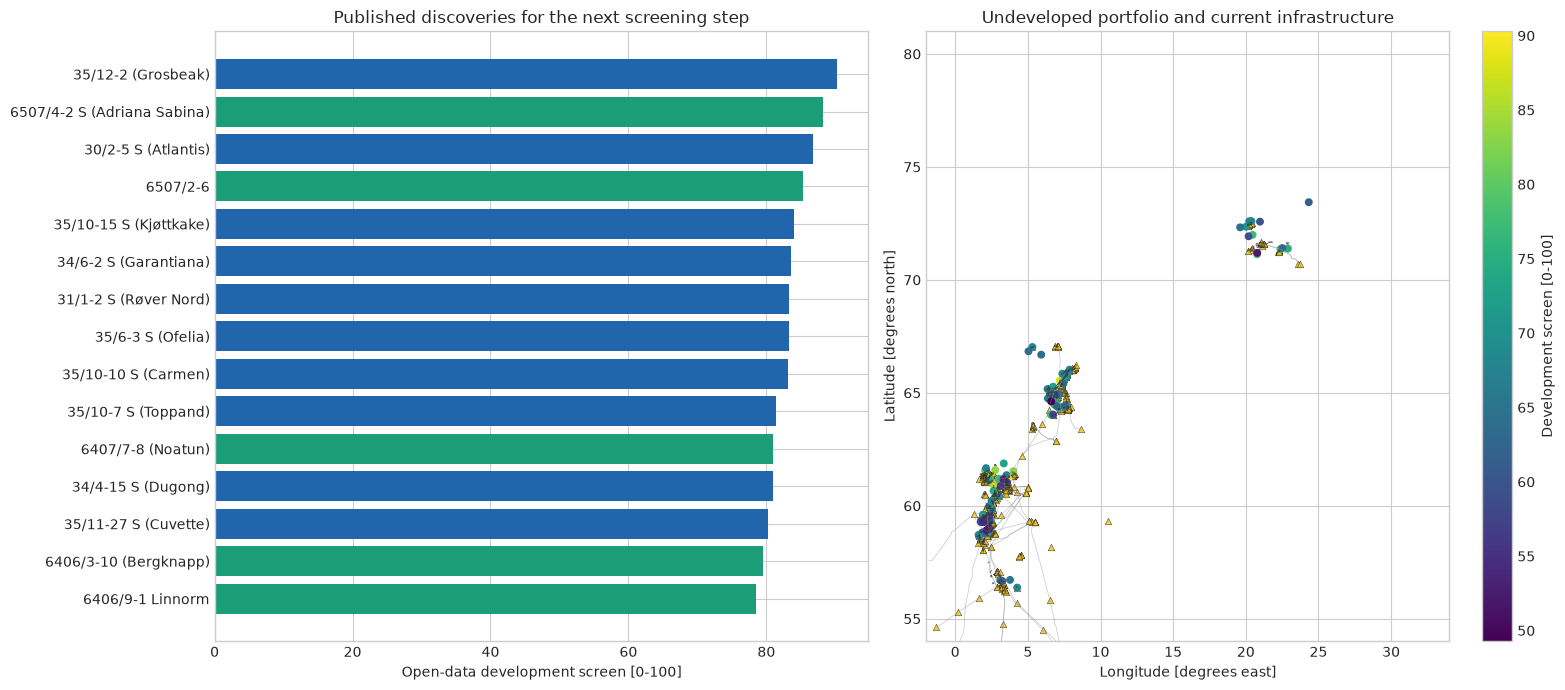

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top_ranked = portfolio.head(15).sort_values("development_screen_score")
bar_colors = [colors.get(area, "#777777") for area in top_ranked["sea_area"]]
axes[0].barh(
    top_ranked["dscName"],
    top_ranked["development_screen_score"],
    color=bar_colors,
)
axes[0].set_xlabel("Open-data development screen [0-100]")
axes[0].set_title("Published discoveries for the next screening step")

pipelines.plot(
    ax=axes[1],
    color="#8d8d8d",
    linewidth=0.45,
    alpha=0.55,
)
fields.boundary.plot(
    ax=axes[1],
    color="#333333",
    linewidth=0.55,
    alpha=0.65,
)
facilities.plot(
    ax=axes[1],
    color="#f1c40f",
    edgecolor="#222222",
    marker="^",
    markersize=22,
    linewidth=0.4,
    alpha=0.8,
)
portfolio.plot(
    ax=axes[1],
    column="development_screen_score",
    cmap="viridis",
    markersize=22,
    legend=True,
    legend_kwds={"label": "Development screen [0-100]"},
)
axes[1].set_xlim(-2, 34)
axes[1].set_ylim(54, 81)
axes[1].set_xlabel("Longitude [degrees east]")
axes[1].set_ylabel("Latitude [degrees north]")
axes[1].set_title("Undeveloped portfolio and current infrastructure")
axes[1].set_aspect("auto")
plt.tight_layout()
plt.show()


## 5. Sea-area opportunity archetypes

The future is not represented by one shelf-wide score. The North Sea's long history creates
a high-information, infrastructure-led opportunity set. The Norwegian Sea combines mature
clusters with areas where gas evacuation and host timing matter. The Barents Sea contains
the largest official share of undiscovered potential, but also the greatest geological,
infrastructure, export, environmental, and schedule uncertainty.

SODIR's 2025 resource accounts report that reserves comprise 59% of remaining North Sea
resources, while undiscovered resources comprise 56% in the Norwegian Sea and 82% in the
Barents Sea. Those percentages have different complements. The comparison below therefore
uses SODIR's expected undiscovered volumes: 545, 745, and 2,190 million Sm$^3$ o.e. for the
North Sea, Norwegian Sea, and Barents Sea, respectively.


,mapped_plays,confirmed_plays,confirmed_play_share,recent_wildcats,recent_discovery_wells,recent_discovery_well_fraction,screened_discoveries,published_contingent_oe_MSm3,median_facility_distance_km,official_undiscovered_resources_MSm3_oe,history_archetype
North Sea,25,21,0.840,191,93,0.487,52,215.627,6.993,545.0,"Mature clusters: near-field exploration, tie..."
Norwegian Sea,21,12,0.571,72,38,0.528,28,128.782,5.513,745.0,"Cluster-led: host timing, gas evacuation, se..."
Barents Sea,25,15,0.600,53,27,0.509,13,142.161,19.399,2190.0,Frontier-weighted: larger uncertainty and in...


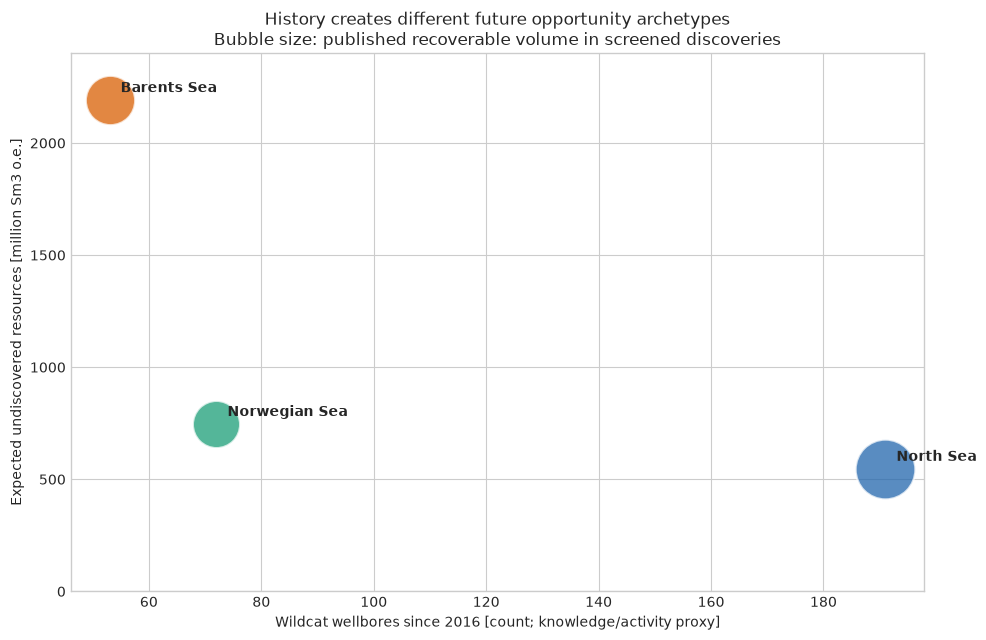

In [10]:
official_undiscovered_volume = pd.Series(
    {
        "North Sea": 545.0,
        "Norwegian Sea": 745.0,
        "Barents Sea": 2_190.0,
    },
    name="official_undiscovered_resources_MSm3_oe",
)
recent_wildcats = wildcat_history.query("year >= 2016").copy()
recent_summary = recent_wildcats.groupby("sea_area").agg(
    recent_wildcats=("wlbNpdidWellbore", "count"),
    recent_discovery_wells=("discovery_well", "sum"),
)
recent_summary["recent_discovery_well_fraction"] = (
    recent_summary["recent_discovery_wells"]
    / recent_summary["recent_wildcats"].replace(0, np.nan)
)
portfolio_summary = portfolio.groupby("sea_area").agg(
    screened_discoveries=("dscNpdidDiscovery", "count"),
    published_contingent_oe_MSm3=("dscRecoverableOe", "sum"),
    median_facility_distance_km=("nearest_facility_km", "median"),
)
area_scorecard = (
    play_summary.join(recent_summary, how="outer")
    .join(portfolio_summary, how="outer")
    .join(official_undiscovered_volume, how="outer")
    .reindex(areas)
)
area_scorecard["history_archetype"] = [
    "Mature clusters: near-field exploration, tie-ins, IOR/EOR",
    "Cluster-led: host timing, gas evacuation, selective frontier tests",
    "Frontier-weighted: larger uncertainty and infrastructure dependence",
]
display(area_scorecard.round(3))

fig, axis = plt.subplots(figsize=(10, 6.5))
bubble_size = (
    120
    + 8
    * area_scorecard["published_contingent_oe_MSm3"]
    .fillna(0.0)
    .clip(upper=250)
)
for sea_area in areas:
    row = area_scorecard.loc[sea_area]
    axis.scatter(
        row["recent_wildcats"],
        row["official_undiscovered_resources_MSm3_oe"],
        s=bubble_size.loc[sea_area],
        color=colors[sea_area],
        alpha=0.75,
        edgecolor="white",
        linewidth=1.5,
    )
    axis.annotate(
        sea_area,
        (row["recent_wildcats"], row["official_undiscovered_resources_MSm3_oe"]),
        xytext=(8, 6),
        textcoords="offset points",
        fontsize=10,
        weight="bold",
    )
axis.set_xlabel("Wildcat wellbores since 2016 [count; knowledge/activity proxy]")
axis.set_ylabel("Expected undiscovered resources [million Sm3 o.e.]")
axis.set_ylim(0.0, 2_400.0)
axis.set_title(
    "History creates different future opportunity archetypes\n"
    "Bubble size: published recoverable volume in screened discoveries"
)
plt.tight_layout()
plt.show()


## 6. NeqSim tie-back pressure-margin screen

The three highest-scoring gas-bearing discoveries are represented by one generic
gas-condensate fluid. The public recoverable-gas estimate is converted to an illustrative
20-year plateau proxy,

$$q_{g,\mathrm{screen}}=\min\left(5,\max\left(0.5,\frac{1000G}{20\times365}\right)\right)$$

where $G$ is recoverable gas in billion Sm$^3$ and $q_g$ is in million Sm$^3$/day. A
straight-line distance to the nearest SODIR facility is used as pipe length. The common
160 bara, 55 °C inlet, 400 mm pipe, 5 °C ambient, and generic fluid are deliberately held
constant. The result is a model-integration demonstration and pressure-screening bound,
not a recommended concept.


In [11]:
J = jpype.JClass
SystemSrkEos = J("neqsim.thermo.system.SystemSrkEos")
Stream = J("neqsim.process.equipment.stream.Stream")
PipeBeggsAndBrills = J(
    "neqsim.process.equipment.pipeline.PipeBeggsAndBrills"
)


def make_generic_gas_condensate():
    fluid = SystemSrkEos(273.15 + 55.0, 160.0)
    composition = {
        "nitrogen": 0.005,
        "CO2": 0.015,
        "methane": 0.835,
        "ethane": 0.075,
        "propane": 0.035,
        "n-butane": 0.015,
        "n-pentane": 0.008,
        "n-hexane": 0.005,
        "water": 0.007,
    }
    assert abs(sum(composition.values()) - 1.0) < 1.0e-12
    for component, fraction in composition.items():
        fluid.addComponent(component, fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid


def run_tieback_screen(name, length_km, gas_bsm3, diameter_m=0.40):
    plateau_rate = 1000.0 * max(float(gas_bsm3), 0.0) / (20.0 * 365.0)
    plateau_rate = float(np.clip(plateau_rate, 0.5, 5.0))

    inlet = Stream(f"{name} screening inlet", make_generic_gas_condensate())
    inlet.setFlowRate(plateau_rate, "MSm3/day")
    inlet.setTemperature(55.0, "C")
    inlet.setPressure(160.0, "bara")
    inlet.run()

    pipe = PipeBeggsAndBrills(f"{name} generic tie-back", inlet)
    pipe.setLength(max(float(length_km), 1.0) * 1_000.0)
    pipe.setDiameter(diameter_m)
    pipe.setPipeWallRoughness(4.5e-5)
    pipe.setElevation(0.0)
    pipe.setNumberOfIncrements(max(30, int(length_km)))
    pipe.setConstantSurfaceTemperature(5.0, "C")
    pipe.setHeatTransferCoefficient(2.2)
    pipe.run()

    outlet = pipe.getOutletStream()
    return {
        "discovery": name,
        "length_km": float(length_km),
        "diameter_m": diameter_m,
        "screen_rate_MSm3_d": plateau_rate,
        "arrival_pressure_bara": outlet.getPressure("bara"),
        "arrival_temperature_C": outlet.getTemperature("C"),
        "relative_flow_imbalance": abs(
            outlet.getFlowRate("kg/hr") - inlet.getFlowRate("kg/hr")
        )
        / inlet.getFlowRate("kg/hr"),
    }


gas_candidates = portfolio[
    portfolio["dscHcType"].fillna("").str.contains("GAS", case=False)
    & portfolio["dscRecoverableGas"].fillna(0.0).gt(0.0)
].head(3)
tieback_rows = []
for _, candidate in gas_candidates.iterrows():
    tieback_rows.append(
        run_tieback_screen(
            candidate["dscName"],
            candidate["nearest_facility_km"],
            candidate["dscRecoverableGas"],
        )
    )
tieback_results = pd.DataFrame(tieback_rows)
tieback_results["pressure_margin_to_70_bara"] = (
    tieback_results["arrival_pressure_bara"] - 70.0
)
display(tieback_results.round(3))


,discovery,length_km,diameter_m,screen_rate_MSm3_d,arrival_pressure_bara,arrival_temperature_C,relative_flow_imbalance,pressure_margin_to_70_bara
0,35/12-2 (Grosbeak),9.200,0.4,1.088,159.911,30.237,0.0,89.911
1,6507/4-2 S (Adriana Sabina),3.383,0.4,0.912,159.976,41.834,0.0,89.976
2,30/2-5 S (Atlantis),14.906,0.4,1.078,159.864,21.680,0.0,89.864


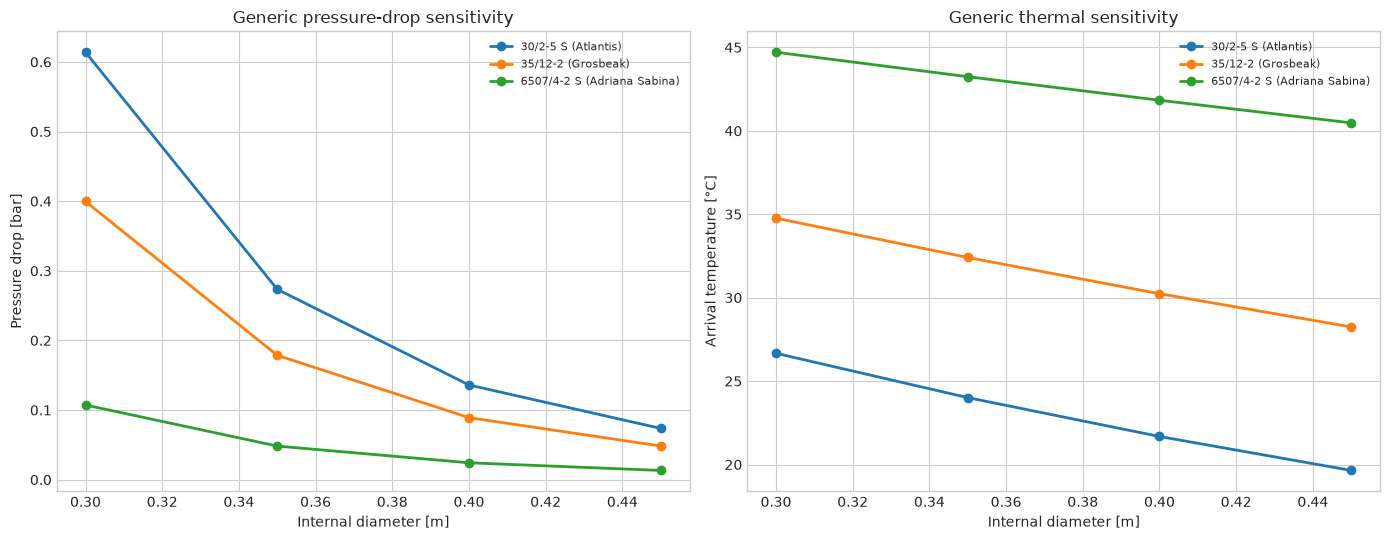

In [12]:
sensitivity_rows = []
for _, candidate in gas_candidates.iterrows():
    for diameter_m in [0.30, 0.35, 0.40, 0.45]:
        result = run_tieback_screen(
            candidate["dscName"],
            candidate["nearest_facility_km"],
            candidate["dscRecoverableGas"],
            diameter_m=diameter_m,
        )
        sensitivity_rows.append(result)
sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity["pressure_drop_bar"] = (
    160.0 - sensitivity["arrival_pressure_bara"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for discovery_name, subset in sensitivity.groupby("discovery"):
    axes[0].plot(
        subset["diameter_m"],
        subset["pressure_drop_bar"],
        marker="o",
        linewidth=2,
        label=discovery_name,
    )
    axes[1].plot(
        subset["diameter_m"],
        subset["arrival_temperature_C"],
        marker="o",
        linewidth=2,
        label=discovery_name,
    )
axes[0].set_xlabel("Internal diameter [m]")
axes[0].set_ylabel("Pressure drop [bar]")
axes[0].set_title("Generic pressure-drop sensitivity")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("Internal diameter [m]")
axes[1].set_ylabel("Arrival temperature [°C]")
axes[1].set_title("Generic thermal sensitivity")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


## 7. Interpretation: what history changes about the opportunity set

1. **North Sea:** the earliest exploration and infrastructure create many short-distance
   screening opportunities. The main uncertainty moves from regional access toward host
   lifetime, process compatibility, late-life reliability, tariffs, and coordinated
   capacity use.
2. **Norwegian Sea:** the portfolio is more cluster-dependent. Gas composition, export
   pressure, pipeline capacity, compressor configuration, and host timing can dominate a
   discovery's value.
3. **Barents Sea:** official undiscovered-resource share is highest, but direct transfer of
   North Sea tie-back logic is unsafe. Sparse infrastructure, gas-export limitations,
   environmental constraints, long schedules, and wider subsurface uncertainty require
   area solutions and scenario analysis.
4. **History creates path dependence:** a discovery made today is evaluated against hosts,
   export routes, ownership structures, and knowledge accumulated by earlier licences and
   wells. The same subsurface volume can therefore have very different development value in
   different areas and decades.

### Continue the NeqSim-Colab learning path

- Use `ncs_area_opening_licensing_exploration_to_discovery.ipynb` for the legal and
  probabilistic exploration evidence chain.
- Use `earth_tools_and_field_development.ipynb` for bathymetry, exclusions, and least-cost
  routing.
- Use `ncs_discovery_1_tie_in_opm_neqsim_master.ipynb` for a reservoir-to-host decision.
- Use `discovery_1_dg1_surf_facilities_design.ipynb` to mature a selected case into DG1.
- Use `norwegian_ncs_gas_network_optimization.ipynb` for transport and market constraints.


## 8. Validation, limitations, and suggested extensions

**Validation level:** official-source provenance plus geometry/identifier checks,
descriptive historical consistency, mass-flow conservation in NeqSim, and expected
diameter/pressure trends. No proprietary calibration or independent commercial model is
used.

**Important limitations**

- FactMaps is a changing public snapshot; reruns can legitimately change counts and ranks.
- Straight-line proximity understates route length and ignores bathymetry and exclusions.
- Remaining field resources are not processing or transport capacity.
- Resource classes, uncertainty ranges, discovery combinations, and operator plans need
  case-specific review.
- The generic fluid does not represent any named discovery's PVT, contaminants, hydrates,
  wax, scale, corrosion, slugging, or liquid handling.
- Undiscovered-resource shares are area aggregates, not prospect-level probabilities.
- Economics, emissions, power, fisheries, protected areas, safety, ownership, and schedule
  are outside the score.

**Suggested extensions**

1. Replace nearest-distance lines with exclusion-aware routes and bathymetry.
2. Add SODIR production, cessation, and field-status history to quantify host lifetime.
3. Sample uncertainty in resources, rates, PVT, route, CAPEX, and host availability.
4. Couple selected discoveries to OPM Flow and a full NeqSim `ProcessSystem`.
5. Compare individual and coordinated area-development solutions.


In [13]:
checks = {
    "exact NeqSim master SHA recorded": len(NEQSIM_SOURCE_COMMIT) == 40,
    "source-built JAR loaded": SOURCE_JAR.name in LOADED_JAR_LOCATION,
    "all key SODIR datasets non-empty": all(
        len(frame) > 0
        for frame in [
            discoveries,
            fields,
            facilities,
            pipelines,
            wildcats,
            plays,
            licences,
            discovery_resources,
            field_resources,
        ]
    ),
    "unique discovery identifiers": discoveries[
        "dscNpdidDiscovery"
    ].is_unique,
    "unique field identifiers": fields["fldNpdidField"].is_unique,
    "portfolio has finite scores": np.isfinite(
        portfolio["development_screen_score"]
    ).all(),
    "portfolio distances are non-negative": (
        portfolio[
            [
                "nearest_facility_km",
                "nearest_pipeline_km",
                "nearest_field_km",
            ]
        ]
        >= 0.0
    ).all().all(),
    "NeqSim cases executed": len(tieback_results) == 3,
    "NeqSim flow imbalance below 1e-8": (
        tieback_results["relative_flow_imbalance"] < 1.0e-8
    ).all(),
    "arrival pressure rises with diameter": sensitivity.groupby(
        "discovery"
    )["arrival_pressure_bara"].apply(lambda values: values.is_monotonic_increasing).all(),
    "all NeqSim outputs finite": np.isfinite(
        sensitivity[
            [
                "arrival_pressure_bara",
                "arrival_temperature_C",
                "relative_flow_imbalance",
            ]
        ]
    ).all().all(),
}
validation = pd.DataFrame(
    {"check": checks.keys(), "passed": checks.values()}
)
display(validation)
assert validation["passed"].all()
print(f"All {len(validation)} validation gates passed.")


All 11 validation gates passed.


,check,passed
0,exact NeqSim master SHA recorded,True
1,source-built JAR loaded,True
2,all key SODIR datasets non-empty,True
3,unique discovery identifiers,True
4,unique field identifiers,True
5,portfolio has finite scores,True
6,portfolio distances are non-negative,True
7,NeqSim cases executed,True
8,NeqSim flow imbalance below 1e-8,True
9,arrival pressure rises with diameter,True


## References and reproducibility

- [SODIR open data](https://www.sodir.no/en/facts/data-and-analyses/open-data/)
- [SODIR FactMaps ArcGIS REST service](https://factmaps.sodir.no/api/rest/services/Factmaps/FactMapsWGS84/FeatureServer)
- [Norway's petroleum history](https://www.norskpetroleum.no/en/framework/norways-petroleum-history/)
- [Historical NCS production](https://www.norskpetroleum.no/en/facts/historical-production/)
- [SODIR Resource Accounts 2025](https://www.sodir.no/en/whats-new/publications/reports/resource-accounts/resource-accounts-2025/resource-accounts/)
- [SODIR Resource Accounts 2025: undiscovered resources](https://www.sodir.no/en/whats-new/publications/reports/resource-accounts/resource-accounts-2025/undiscovered-resources/)
- [SODIR Resource Report 2024: remaining resources](https://www.sodir.no/en/whats-new/publications/reports/resource-report/resource-report-2024/remaining-resources/)
- [SODIR plays](https://www.sodir.no/en/facts/plays/)
- [SODIR production licences](https://www.sodir.no/en/facts/production-licences/)
- [NeqSim](https://github.com/equinor/neqsim)

SODIR data are used under NLOD 2.0. The notebook records retrieval time, package versions,
the exact NeqSim Java commit, the runtime JAR SHA-256, and retained execution outputs.
